In [1]:
import os

os.chdir(r"C:\SentimentScope")

print("Current project folder:")
print(os.getcwd())

Current project folder:
C:\SentimentScope


In [2]:
print("SentimentScope project started successfully!")

SentimentScope project started successfully!


In [3]:
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import transformers

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Transformers version:", transformers.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available - using CPU")

ModuleNotFoundError: No module named 'pandas'

In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn transformers tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import transformers

print("All required libraries loaded successfully!")
print()
print("PyTorch:", torch.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available - using CPU")

C:\Users\vv504\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All required libraries loaded successfully!

PyTorch: 2.14.1+cpu
Pandas: 3.0.6
NumPy: 2.5.3
Transformers: 5.18.0
CUDA available: False
GPU not available - using CPU


In [2]:
import os

print("Files and folders inside SentimentScope:")
print()

for item in os.listdir(r"C:\SentimentScope"):
    print(item)

Files and folders inside SentimentScope:

.ipynb_checkpoints
SentimentScope.ipynb


In [3]:
import os
import urllib.request

dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset_path = r"C:\SentimentScope\aclImdb_v1.tar.gz"

if os.path.exists(dataset_path):
    print("IMDB dataset already exists.")
else:
    print("Downloading IMDB dataset...")
    print("This may take a few minutes because the file is large.")
    
    urllib.request.urlretrieve(dataset_url, dataset_path)
    
    print("Download completed successfully!")

print()
print("Dataset file exists:", os.path.exists(dataset_path))
print("Dataset path:", dataset_path)

This may take a few minutes because the file is large.
Download completed successfully!

Dataset file exists: True
Dataset path: C:\SentimentScope\aclImdb_v1.tar.gz


In [4]:
import os
import tarfile

dataset_path = r"C:\SentimentScope\aclImdb_v1.tar.gz"
extract_path = r"C:\SentimentScope"

print("Extracting IMDB dataset...")
print("Please wait...")

with tarfile.open(dataset_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed successfully!")

print()
print("Extracted folders:")
for item in os.listdir(extract_path):
    print(item)

Extracting IMDB dataset...
Please wait...


C:\Users\vv504\AppData\Local\Temp\ipykernel_23320\924176505.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction completed successfully!

Extracted folders:
.ipynb_checkpoints
aclImdb
aclImdb_v1.tar.gz
SentimentScope.ipynb


In [5]:
import os

base_path = r"C:\SentimentScope\aclImdb"

folders = [
    r"train\pos",
    r"train\neg",
    r"test\pos",
    r"test\neg"
]

print("Checking IMDB dataset folders...")
print()

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    
    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        print(f"✓ {folder} : {len(files)} files")
    else:
        print(f"✗ {folder} : NOT FOUND")

Checking IMDB dataset folders...

✓ train\pos : 12500 files
✓ train\neg : 12500 files
✓ test\pos : 12500 files
✓ test\neg : 12500 files


In [6]:
import os

def load_dataset(folder):
    """
    Reads all text files from a folder
    and returns their contents as a list.
    """
    reviews = []

    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)

        if os.path.isfile(file_path) and filename.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8") as file:
                reviews.append(file.read())

    return reviews

print("load_dataset() function created successfully!")

load_dataset() function created successfully!


In [7]:
train_pos_path = r"C:\SentimentScope\aclImdb\train\pos"
train_neg_path = r"C:\SentimentScope\aclImdb\train\neg"

test_pos_path = r"C:\SentimentScope\aclImdb\test\pos"
test_neg_path = r"C:\SentimentScope\aclImdb\test\neg"

print("Dataset paths set successfully!")

Dataset paths set successfully!


In [8]:
print("Loading training positive reviews...")
train_pos = load_dataset(train_pos_path)

print("Loading training negative reviews...")
train_neg = load_dataset(train_neg_path)

print("Loading testing positive reviews...")
test_pos = load_dataset(test_pos_path)

print("Loading testing negative reviews...")
test_neg = load_dataset(test_neg_path)

print()
print("Dataset loading completed!")
print()
print("Training positive:", len(train_pos))
print("Training negative:", len(train_neg))
print("Testing positive:", len(test_pos))
print("Testing negative:", len(test_neg))

Loading training positive reviews...
Loading training negative reviews...
Loading testing positive reviews...
Loading testing negative reviews...

Dataset loading completed!

Training positive: 12500
Training negative: 12500
Testing positive: 12500
Testing negative: 12500


In [9]:
import pandas as pd

# Create training DataFrame
train_df = pd.DataFrame({
    "review": train_pos + train_neg,
    "label": [1] * len(train_pos) + [0] * len(train_neg)
})

# Create testing DataFrame
test_df = pd.DataFrame({
    "review": test_pos + test_neg,
    "label": [1] * len(test_pos) + [0] * len(test_neg)
})

print("DataFrames created successfully!")
print()

print("Training DataFrame shape:", train_df.shape)
print("Testing DataFrame shape:", test_df.shape)

DataFrames created successfully!

Training DataFrame shape: (25000, 2)
Testing DataFrame shape: (25000, 2)


In [10]:
# Check training dataset dimensions
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."

# Check testing dataset dimensions
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

print("All dimension checks passed successfully!")
print()
print("Training dataset:", train_df.shape)
print("Testing dataset:", test_df.shape)

All dimension checks passed successfully!

Training dataset: (25000, 2)
Testing dataset: (25000, 2)


In [11]:
print("Training DataFrame information:")
print()
train_df.info()

print("\n" + "=" * 60)
print("Training DataFrame descriptive statistics:")
print()
print(train_df.describe(include="all"))

Training DataFrame information:

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB

Training DataFrame descriptive statistics:

                                                   review        label
count                                               25000  25000.00000
unique                                              24904          NaN
top     You do realize that you've been watching the E...          NaN
freq                                                    3          NaN
mean                                                  NaN      0.50000
std                                                   NaN      0.50001
min                                                   NaN      0.00000
25%                                                   NaN      0.0000

In [12]:
print("Sentiment distribution:")
print()

label_counts = train_df["label"].value_counts().sort_index()

print("Negative reviews (0):", label_counts[0])
print("Positive reviews (1):", label_counts[1])

Sentiment distribution:

Negative reviews (0): 12500
Positive reviews (1): 12500


In [13]:
# Calculate review length in characters
train_df["review_length"] = train_df["review"].str.len()

print("Review length statistics:")
print()

print(train_df["review_length"].describe())

Review length statistics:

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64


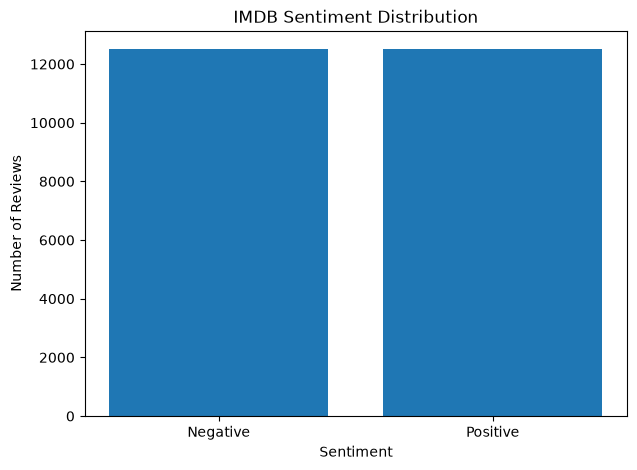

In [14]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Negative", "Positive"],
    [label_counts[0], label_counts[1]]
)

plt.title("IMDB Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

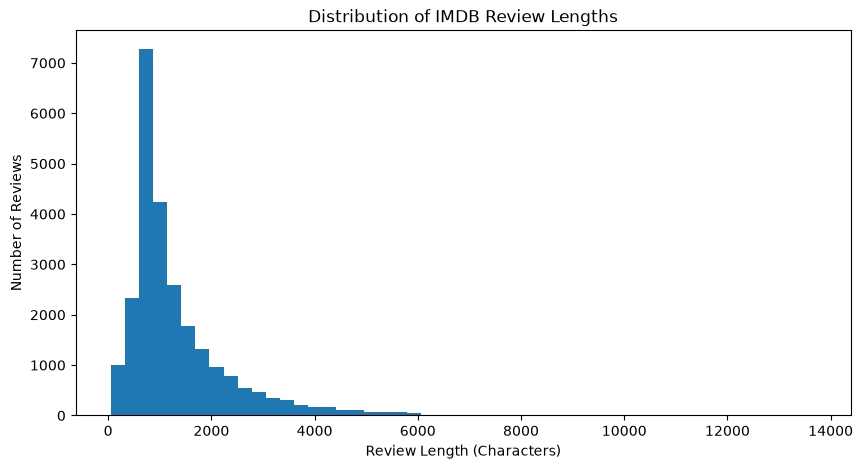

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["review_length"],
    bins=50
)

plt.title("Distribution of IMDB Review Lengths")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

In [16]:
# Shuffle the training data
shuffled_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Use 90% for training
train_size = int(0.9 * len(shuffled_df))

# Split into training and validation sets
train_data = shuffled_df.iloc[:train_size].copy()
val_data = shuffled_df.iloc[train_size:].copy()

print("Dataset split completed!")
print()

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_df))

Dataset split completed!

Training samples: 22500
Validation samples: 2500
Testing samples: 25000


In [17]:
from transformers import BertTokenizer

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("BERT tokenizer loaded successfully!")
print("Tokenizer:", tokenizer.name_or_path)

C:\Users\vv504\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vv504\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


BERT tokenizer loaded successfully!
Tokenizer: bert-base-uncased


In [18]:
sample_text = "This movie was absolutely amazing and enjoyable!"

encoded = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print("Tokenizer test completed!")
print()
print("Input IDs shape:", encoded["input_ids"].shape)
print("Attention mask shape:", encoded["attention_mask"].shape)
print()
print("First 20 token IDs:")
print(encoded["input_ids"][0][:20])

Tokenizer test completed!

Input IDs shape: torch.Size([1, 128])
Attention mask shape: torch.Size([1, 128])

First 20 token IDs:
tensor([  101,  2023,  3185,  2001,  7078,  6429,  1998, 22249,   999,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])


In [19]:
import torch
from torch.utils.data import Dataset

MAX_LENGTH = 128


class IMDBDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        review = self.dataframe.loc[index, "review"]
        label = self.dataframe.loc[index, "label"]

        encoding = self.tokenizer(
            review,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }


print("IMDBDataset class created successfully!")

IMDBDataset class created successfully!


In [20]:
# Create PyTorch Dataset objects
train_dataset = IMDBDataset(
    train_data,
    tokenizer,
    MAX_LENGTH
)

val_dataset = IMDBDataset(
    val_data,
    tokenizer,
    MAX_LENGTH
)

test_dataset = IMDBDataset(
    test_df,
    tokenizer,
    MAX_LENGTH
)

print("Dataset objects created successfully!")
print()

print("Training dataset length:", len(train_dataset))
print("Validation dataset length:", len(val_dataset))
print("Testing dataset length:", len(test_dataset))

print()
print("Training dataset type:", type(train_dataset))
print("Validation dataset type:", type(val_dataset))
print("Testing dataset type:", type(test_dataset))

Dataset objects created successfully!

Training dataset length: 22500
Validation dataset length: 2500
Testing dataset length: 25000

Training dataset type: <class '__main__.IMDBDataset'>
Validation dataset type: <class '__main__.IMDBDataset'>
Testing dataset type: <class '__main__.IMDBDataset'>


In [21]:
sample = train_dataset[0]

print("Sample retrieved successfully!")
print()

print("Keys:", sample.keys())
print()
print("Input IDs shape:", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Label:", sample["labels"])
print("Input IDs data type:", sample["input_ids"].dtype)
print("Attention mask data type:", sample["attention_mask"].dtype)
print("Label data type:", sample["labels"].dtype)

Sample retrieved successfully!

Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: tensor(1)
Input IDs data type: torch.int64
Attention mask data type: torch.int64
Label data type: torch.int64


In [22]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully!")
print()

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!

Batch size: 16
Training batches: 1407
Validation batches: 157
Testing batches: 1563


In [24]:
# Get one batch from the training DataLoader
batch = next(iter(train_loader))

print("Batch retrieved successfully!")
print()

print("Input IDs shape:", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape:", batch["labels"].shape)

print()
print("First 5 labels:", batch["labels"][:5])

Batch retrieved successfully!

Input IDs shape: torch.Size([16, 128])
Attention mask shape: torch.Size([16, 128])
Labels shape: torch.Size([16])

First 5 labels: tensor([0, 0, 0, 1, 1])


In [25]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Token embedding layer
        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"],
            config["d_embed"]
        )

        # Positional embedding layer
        self.positional_embedding_layer = nn.Embedding(
            config["context_size"],
            config["d_embed"]
        )

        # Transformer layers
        blocks = [
            Block(config)
            for _ in range(config["layers_num"])
        ]

        self.layers = nn.Sequential(*blocks)

        # Layer normalization
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # Classification output layer
        self.classification_head = nn.Linear(
            config["d_embed"],
            config["num_classes"],
            bias=False
        )

    def forward(self, token_ids):

        batch_size, tokens_num = token_ids.shape

        # Token embeddings
        x = self.token_embedding_layer(token_ids)

        # Positional embeddings
        positions = torch.arange(
            tokens_num,
            device=token_ids.device
        )

        pos_embed = self.positional_embedding_layer(positions)

        x = x + pos_embed.unsqueeze(0)

        # Transformer layers
        x = self.layers(x)

        # Layer normalization
        x = self.layer_norm(x)

        # Mean pooling
        x = torch.mean(x, dim=1)

        # Classification logits
        logits = self.classification_head(x)

        return logits

NameError: name 'nn' is not defined

In [26]:
import torch
import torch.nn as nn

print("PyTorch neural network module loaded successfully!")

PyTorch neural network module loaded successfully!


In [27]:
# Create the model
demo_gpt = DemoGPT(config).to(device)

print("DemoGPT model created successfully!")

# Create dummy input
dummy_input = torch.randint(
    0,
    config["vocabulary_size"],
    (32, config["context_size"])
).to(device)

# Forward pass
dummy_output = demo_gpt(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Dummy output shape:", dummy_output.shape)

# Check expected output
assert dummy_output.shape == (32, config["num_classes"])

print("Output shape assertion passed!")

NameError: name 'DemoGPT' is not defined

In [28]:
import torch
import torch.nn as nn

print("Imports ready!")

Imports ready!


In [30]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"],
            config["d_embed"]
        )

        self.positional_embedding_layer = nn.Embedding(
            config["context_size"],
            config["d_embed"]
        )

        blocks = [
            Block(config)
            for _ in range(config["layers_num"])
        ]

        self.layers = nn.Sequential(*blocks)

        self.layer_norm = nn.LayerNorm(config["d_embed"])

        self.classification_head = nn.Linear(
            config["d_embed"],
            config["num_classes"],
            bias=False
        )

    def forward(self, token_ids):
        batch_size, tokens_num = token_ids.shape

        x = self.token_embedding_layer(token_ids)

        positions = torch.arange(
            tokens_num,
            device=token_ids.device
        )

        pos_embed = self.positional_embedding_layer(positions)

        x = x + pos_embed.unsqueeze(0)

        x = self.layers(x)

        x = self.layer_norm(x)

        x = torch.mean(x, dim=1)

        logits = self.classification_head(x)

        return logits


print("DemoGPT class created successfully!")

DemoGPT class created successfully!


In [31]:
demo_gpt = DemoGPT(config).to(device)

print("DemoGPT model created successfully!")

dummy_input = torch.randint(
    0,
    config["vocabulary_size"],
    (32, config["context_size"])
).to(device)

dummy_output = demo_gpt(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Dummy output shape:", dummy_output.shape)

assert dummy_output.shape == (32, config["num_classes"])

print("Output shape assertion passed!")

NameError: name 'config' is not defined

In [32]:
print("config" in globals())

False


In [33]:
print("DemoGPT" in globals())

True


In [34]:
demo_gpt = DemoGPT(config).to(device)

NameError: name 'config' is not defined

In [35]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "head_size": 32,
    "heads_num": 4,
    "layers_num": 4,
    "dropout_rate": 0.1,
    "use_bias": True,
    "num_classes": 2
}

print("Configuration created successfully!")
print(config)

Configuration created successfully!
{'vocabulary_size': 30522, 'd_embed': 128, 'context_size': 128, 'head_size': 32, 'heads_num': 4, 'layers_num': 4, 'dropout_rate': 0.1, 'use_bias': True, 'num_classes': 2}


In [36]:
demo_gpt = DemoGPT(config).to(device)

print("DemoGPT model created successfully!")

NameError: name 'Block' is not defined

In [37]:
import torch
import torch.nn as nn
import math


class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.Q_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.K_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.V_weights = nn.Linear(
            config["d_embed"],
            config["head_size"],
            bias=config["use_bias"]
        )

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(
            torch.ones(
                config["context_size"],
                config["context_size"]
            )
        )

        self.register_buffer(
            "casual_attention_mask",
            casual_attention_mask
        )

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape

        Q = self.Q_weights(input)
        K = self.K_weights(input)
        V = self.V_weights(input)

        attention_scores = Q @ K.transpose(1, 2)

        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float("-inf")
        )

        attention_scores = attention_scores / math.sqrt(K.shape[-1])

        attention_scores = torch.softmax(
            attention_scores,
            dim=-1
        )

        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.heads = nn.ModuleList(
            [
                AttentionHead(config)
                for _ in range(config["heads_num"])
            ]
        )

        self.projection = nn.Linear(
            config["heads_num"] * config["head_size"],
            config["d_embed"],
            bias=config["use_bias"]
        )

        self.dropout = nn.Dropout(
            config["dropout_rate"]
        )

    def forward(self, input):
        x = torch.cat(
            [head(input) for head in self.heads],
            dim=-1
        )

        x = self.projection(x)

        x = self.dropout(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                config["d_embed"],
                4 * config["d_embed"],
                bias=config["use_bias"]
            ),
            nn.GELU(),
            nn.Linear(
                4 * config["d_embed"],
                config["d_embed"],
                bias=config["use_bias"]
            ),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.network(input)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)

        self.layer_norm_1 = nn.LayerNorm(
            config["d_embed"]
        )

        self.feed_forward = FeedForward(config)

        self.layer_norm_2 = nn.LayerNorm(
            config["d_embed"]
        )

    def forward(self, input):
        x = input

        x = x + self.multi_head(
            self.layer_norm_1(x)
        )

        x = x + self.feed_forward(
            self.layer_norm_2(x)
        )

        return x


print("Transformer supporting classes created successfully!")

Transformer supporting classes created successfully!


In [38]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"],
            config["d_embed"]
        )

        self.positional_embedding_layer = nn.Embedding(
            config["context_size"],
            config["d_embed"]
        )

        blocks = [
            Block(config)
            for _ in range(config["layers_num"])
        ]

        self.layers = nn.Sequential(*blocks)

        self.layer_norm = nn.LayerNorm(
            config["d_embed"]
        )

        self.classification_head = nn.Linear(
            config["d_embed"],
            config["num_classes"],
            bias=False
        )

    def forward(self, token_ids):

        batch_size, tokens_num = token_ids.shape

        x = self.token_embedding_layer(token_ids)

        positions = torch.arange(
            tokens_num,
            device=token_ids.device
        )

        pos_embed = self.positional_embedding_layer(
            positions
        )

        x = x + pos_embed.unsqueeze(0)

        x = self.layers(x)

        x = self.layer_norm(x)

        # Mean pooling across the sequence
        x = torch.mean(x, dim=1)

        # Classification logits
        logits = self.classification_head(x)

        return logits


print("DemoGPT class created successfully!")

DemoGPT class created successfully!


In [39]:
demo_gpt = DemoGPT(config).to(device)

print("DemoGPT model created successfully!")

NameError: name 'device' is not defined

In [40]:
Vimport torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

SyntaxError: invalid syntax (186295316.py, line 1)

In [41]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cpu


In [42]:
demo_gpt = DemoGPT(config).to(device)

print("DemoGPT model created successfully!")

DemoGPT model created successfully!


In [43]:
dummy_input = torch.randint(
    0,
    config["vocabulary_size"],
    (2, config["context_size"])
).to(device)

with torch.no_grad():
    dummy_output = demo_gpt(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Dummy output shape:", dummy_output.shape)

Dummy input shape: torch.Size([2, 128])
Dummy output shape: torch.Size([2, 2])


In [44]:
def calculate_accuracy(logits, labels):
    predictions = torch.argmax(logits, dim=1)
    correct = (predictions == labels).sum().item()
    accuracy = correct / labels.size(0)

    return accuracy


# Test the function
test_logits = torch.tensor([
    [2.0, 1.0],
    [0.5, 2.5],
    [3.0, 1.0],
    [0.2, 4.0]
])

test_labels = torch.tensor([0, 1, 0, 1])

accuracy = calculate_accuracy(test_logits, test_labels)

print("Test accuracy:", accuracy)

Test accuracy: 1.0


In [45]:
import torch.nn as nn
import torch.optim as optim

EPOCHS = 3

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    demo_gpt.parameters(),
    lr=3e-4
)

print("Training setup completed successfully!")
print("Epochs:", EPOCHS)
print("Learning rate:", 3e-4)

Training setup completed successfully!
Epochs: 3
Learning rate: 0.0003


In [46]:
demo_gpt.train()

batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
labels = batch["labels"].to(device)

optimizer.zero_grad()

logits = demo_gpt(input_ids)

loss = criterion(logits, labels)

loss.backward()

optimizer.step()

accuracy = calculate_accuracy(logits, labels)

print("Input shape:", input_ids.shape)
print("Labels shape:", labels.shape)
print("Logits shape:", logits.shape)
print("Loss:", loss.item())
print("Batch accuracy:", accuracy)

Input shape: torch.Size([16, 128])
Labels shape: torch.Size([16])
Logits shape: torch.Size([16, 2])
Loss: 0.6786801218986511
Batch accuracy: 0.5625


In [47]:
from tqdm import tqdm

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    demo_gpt.train()

    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} - Training"
    )

    for batch in train_progress:

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = demo_gpt(input_ids)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(logits, dim=1)
        total_train_correct += (predictions == labels).sum().item()

        total_train_samples += labels.size(0)

    train_loss = total_train_loss / total_train_samples
    train_accuracy = total_train_correct / total_train_samples

    # -------------------------
    # Validation
    # -------------------------
    demo_gpt.eval()

    total_val_loss = 0
    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            logits = demo_gpt(input_ids)

            loss = criterion(logits, labels)

            total_val_loss += loss.item() * labels.size(0)

            predictions = torch.argmax(logits, dim=1)
            total_val_correct += (predictions == labels).sum().item()

            total_val_samples += labels.size(0)

    val_loss = total_val_loss / total_val_samples
    val_accuracy = total_val_correct / total_val_samples

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch 1/3 - Training: 100%|██████████| 1407/1407 [04:54<00:00,  4.77it/s]



Epoch 1/3
Train Loss: 0.6003 | Train Accuracy: 0.6619
Val Loss: 0.5412 | Val Accuracy: 0.7164


Epoch 2/3 - Training: 100%|██████████| 1407/1407 [04:52<00:00,  4.81it/s]



Epoch 2/3
Train Loss: 0.4702 | Train Accuracy: 0.7751
Val Loss: 0.4478 | Val Accuracy: 0.7880


Epoch 3/3 - Training: 100%|██████████| 1407/1407 [05:19<00:00,  4.41it/s]



Epoch 3/3
Train Loss: 0.3957 | Train Accuracy: 0.8206
Val Loss: 0.4197 | Val Accuracy: 0.8092


In [48]:
demo_gpt.eval()

total_test_correct = 0
total_test_samples = 0
total_test_loss = 0

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Testing"):

        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits = demo_gpt(input_ids)

        loss = criterion(logits, labels)

        total_test_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(logits, dim=1)

        total_test_correct += (
            predictions == labels
        ).sum().item()

        total_test_samples += labels.size(0)

test_loss = total_test_loss / total_test_samples
test_accuracy = total_test_correct / total_test_samples

print("\nFinal Test Results")
print("------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Testing: 100%|██████████| 1563/1563 [00:54<00:00, 28.65it/s]


Final Test Results
------------------
Test Loss: 0.4829
Test Accuracy: 0.7702
Test Accuracy: 77.02%


In [49]:
checkpoint_path = r"C:\SentimentScope\sentimentscope_model.pt"

torch.save(
    {
        "model_state_dict": demo_gpt.state_dict(),
        "config": config,
        "test_accuracy": test_accuracy,
    },
    checkpoint_path
)

print("Model checkpoint saved successfully!")
print("Saved to:", checkpoint_path)

Model checkpoint saved successfully!
Saved to: C:\SentimentScope\sentimentscope_model.pt


In [50]:
training_results = {
    "Epoch": [1, 2, 3],
    "Train Loss": [0.6003, 0.4702, 0.3957],
    "Train Accuracy": [0.6619, 0.7751, 0.8206],
    "Validation Loss": [0.5412, 0.4478, 0.4197],
    "Validation Accuracy": [0.7164, 0.7880, 0.8092]
}

results_df = pd.DataFrame(training_results)

print("Training results:")
display(results_df)

Training results:


,Epoch,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy
0,1,0.6003,0.6619,0.5412,0.7164
1,2,0.4702,0.7751,0.4478,0.7880
2,3,0.3957,0.8206,0.4197,0.8092


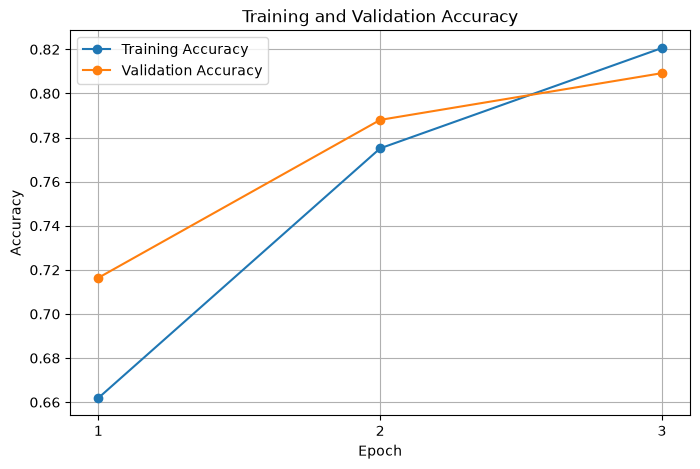

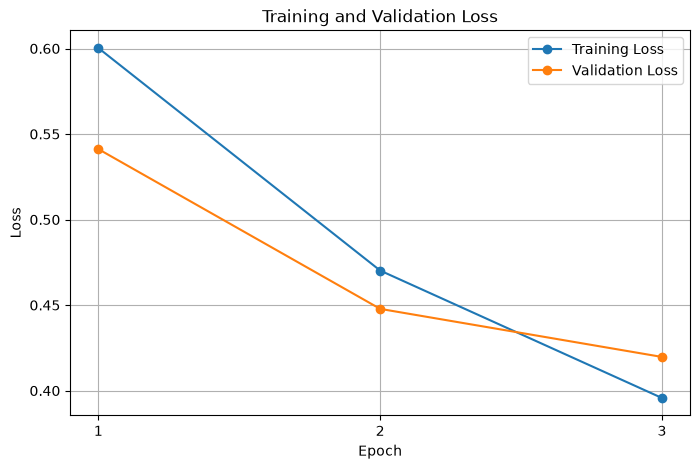

In [51]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Epoch"],
    results_df["Train Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Epoch"],
    results_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(results_df["Epoch"])
plt.legend()
plt.grid(True)
plt.show()


# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Epoch"],
    results_df["Train Loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    results_df["Epoch"],
    results_df["Validation Loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(results_df["Epoch"])
plt.legend()
plt.grid(True)
plt.show()

In [52]:
def predict_sentiment(review_text):
    demo_gpt.eval()

    encoding = tokenizer(
        review_text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)

    with torch.no_grad():
        logits = demo_gpt(input_ids)
        probabilities = torch.softmax(logits, dim=1)
        prediction = torch.argmax(logits, dim=1).item()

    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = probabilities[0, prediction].item()

    return sentiment, confidence


print("Inference function created successfully!")

Inference function created successfully!


In [53]:
review = "This movie was absolutely fantastic. The story was engaging and the performances were excellent."

sentiment, confidence = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence * 100:.2f}%")

Review: This movie was absolutely fantastic. The story was engaging and the performances were excellent.
Predicted Sentiment: Positive
Confidence: 95.86%


In [54]:
review = "This movie was terrible. The story was boring, the acting was poor, and I did not enjoy watching it."

sentiment, confidence = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence * 100:.2f}%")

Review: This movie was terrible. The story was boring, the acting was poor, and I did not enjoy watching it.
Predicted Sentiment: Negative
Confidence: 99.98%


In [55]:
review = "This movie was terrible. The story was boring, the acting was poor, and I did not enjoy watching it."

sentiment, confidence = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence * 100:.2f}%")

Review: This movie was terrible. The story was boring, the acting was poor, and I did not enjoy watching it.
Predicted Sentiment: Negative
Confidence: 99.98%


In [56]:
print("=" * 50)
print("SentimentScope - Final Model Results")
print("=" * 50)

print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nInference Examples:")
print("Positive review → Positive")
print("Negative review → Negative")

print("\nModel checkpoint:")
print(r"C:\SentimentScope\sentimentscope_model.pt")

SentimentScope - Final Model Results
Final Validation Accuracy: 80.92%
Final Test Accuracy: 77.02%
Final Test Loss: 0.4829

Inference Examples:
Positive review → Positive
Negative review → Negative

Model checkpoint:
C:\SentimentScope\sentimentscope_model.pt


In [57]:
SentimentScope - Final Model Results
==================================================
Final Validation Accuracy: 80.92%
Final Test Accuracy: 77.02%
Final Test Loss: 0.4829

Inference Examples:
Positive review → Positive
Negative review → Negative

Model checkpoint:
C:\SentimentScope\sentimentscope_model.pt

SyntaxError: invalid character '→' (U+2192) (2897223911.py, line 8)

In [58]:
print("Hello")

Hello
